In [1]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, GRU, Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import KFold
import numpy as np


In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Conv1D, MaxPooling1D, Flatten, TimeDistributed
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import tensorflow as tf
import random
import os
from sklearn.model_selection import KFold
import datetime

In [3]:
# Set random seeds for reproducibility
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['PYTHONHASHSEED'] = '0'

In [4]:
# File paths
file_paths = {
    "B0005": r"C:\Users\Varshitha\OneDrive\CU notes\RM\VMD_CNN_LSTM_CODE_VIJAY\B0005_ALL_FEATURES_NEW.csv",
    "B0006": r"C:\Users\Varshitha\OneDrive\CU notes\RM\VMD_CNN_LSTM_CODE_VIJAY\B0006_ALL_FEATURES_NEW.csv",
    "B0007": r"C:\Users\Varshitha\OneDrive\CU notes\RM\VMD_CNN_LSTM_CODE_VIJAY\B0007_ALL_FEATURES_NEW.csv",
    "B0018": r"C:\Users\Varshitha\OneDrive\CU notes\RM\VMD_CNN_LSTM_CODE_VIJAY\B0018_ALL_FEATURES_NEW.csv"
}

In [5]:
def load_and_preprocess_data(file_path):
    data = pd.read_csv(file_path)
      # Drop specified columns
    #data = data.drop(columns=['IMF1', 'IMF2', 'IMF3'])
    #group 1
    #data = data.drop(columns=['IMF1', 'IMF2', 'IMF3','CV_CT', 'dQ_dV_peak_positionV'])
    
    # group 2
    data = data.drop(columns=['CC_CT','CV_CT','Ratio_CCCT_CVCT','C_TEMP_MAX','dQ_dV_peak','dQ_dV_peak_positionV','Original_Signal'])

    #group 1 and 2
    #data = data.drop(columns=['CV_CT','dQ_dV_peak', 'dQ_dV_peak_positionV'])
    return data

In [6]:
def create_sliding_window(data, window_size, target_column_index):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size, :])
        y.append(data[i + window_size, target_column_index])
    return np.array(X), np.array(y)

In [8]:
# Define parameters
window_size = 8
Batch_Size = 32
train_files = ["B0005", "B0006", "B0007"]
test_file = "B0018"

In [9]:
# Step 1: Load and preprocess individual datasets
train_processed_data = {}
for file in train_files:
    data = load_and_preprocess_data(file_paths[file])
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(data)
    train_processed_data[file] = {
        'data': scaled_data,
        'columns': data.columns,
        'scaler': scaler
    }

test_data = load_and_preprocess_data(file_paths[test_file])
test_scaler = MinMaxScaler()
test_data_scaled = test_scaler.fit_transform(test_data)

In [10]:
# Step 2: Create sliding windows for each dataset
train_windows = {}
for file in train_files:
    #target_column_index = list(train_processed_data[file]['columns']).index("Original_Signal")
    target_column_index = list(train_processed_data[file]['columns']).index("SOH")
    X, y = create_sliding_window(
        train_processed_data[file]['data'], 
        window_size, 
        target_column_index
    )
    train_windows[file] = {'X': X, 'y': y}

In [11]:
# Step 3: Combine the windowed data
X_combined = np.concatenate([train_windows[file]['X'] for file in train_files])
y_combined = np.concatenate([train_windows[file]['y'] for file in train_files])

print("Combined training data shape:", X_combined.shape)
print("Combined target data shape:", y_combined.shape)

# Create sliding windows for test data
test_target_column_index = test_data.columns.get_loc("SOH")
X_test, y_test = create_sliding_window(test_data_scaled, window_size, test_target_column_index)
print("Test data shape:", X_test.shape)

# Initialize KFold
kf = KFold(n_splits=3, shuffle=True, random_state=42)

# Dictionary to store metrics for each fold
fold_metrics = {}

# Train and evaluate the LSTM model with K-Fold Cross Validation
for fold, (train_index, val_index) in enumerate(kf.split(X_combined)):
    print(f"\nTraining on fold {fold + 1}")
    
    # Split the data
    X_train, X_val = X_combined[train_index], X_combined[val_index]
    y_train, y_val = y_combined[train_index], y_combined[val_index]
    
    # Build the LSTM model
    model = Sequential([
        Input(shape=(X_train.shape[1], X_train.shape[2])),
        LSTM(128, activation='relu', return_sequences=False),
        Dense(64, activation='relu'),
        Dense(1)
    ])
    
    # Compile model
    model.compile(optimizer='adam', loss='mse')
    
    # Early stopping
    early_stopping = EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True)
    
    # Train model
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=1000,
        batch_size=Batch_Size,
        callbacks=[early_stopping],
        verbose=1
    )
    
    # Store metrics
    fold_metrics[fold] = {
        'val_loss': min(history.history['val_loss']),
        'train_loss': min(history.history['loss'])
    }

# Print average metrics
avg_val_loss = np.mean([metrics['val_loss'] for metrics in fold_metrics.values()])
print(f"\nAverage validation loss across folds: {avg_val_loss}")

# Evaluate on test data
test_loss = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {test_loss}")

# Predict on test data
y_pred = model.predict(X_test)

# Inverse transform predictions
y_test_actual = test_scaler.inverse_transform(
    np.concatenate((np.zeros((len(y_test), test_data.shape[1] - 1)), y_test.reshape(-1, 1)), axis=1)
)[:, -1]
y_pred_actual = test_scaler.inverse_transform(
    np.concatenate((np.zeros((len(y_pred), test_data.shape[1] - 1)), y_pred), axis=1)
)[:, -1]


Combined training data shape: (480, 8, 4)
Combined target data shape: (480,)
Test data shape: (124, 8, 4)

Training on fold 1
Epoch 1/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 162ms/step - loss: 0.1731 - val_loss: 0.0655
Epoch 2/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0317 - val_loss: 0.0238
Epoch 3/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0136 - val_loss: 0.0101
Epoch 4/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0034 - val_loss: 0.0015
Epoch 5/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0014 - val_loss: 0.0012
Epoch 6/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0012 - val_loss: 0.0011
Epoch 7/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 7.1891e-04 - val_loss: 8.4407e-04
Epoch 8/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 6.6369e-04 - val_loss: 7.2247e-04
Epoch 9/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 6.3215e-04 - val_loss: 7.3911e-04
Epoch 10/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 5.79

In [12]:
# Calculate metrics
mae = mean_absolute_error(y_test_actual, y_pred_actual)
mse = mean_squared_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_actual, y_pred_actual)
mape = np.mean(np.abs((y_test_actual - y_pred_actual) / y_test_actual)) * 100

# Print metrics
print("\nFinal Model Performance Metrics:")
print(f"Mean Absolute Error (MAE): {mae:.10f}")
print(f"Mean Squared Error (MSE): {mse:.10f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.10f}")
print(f"R2 Score: {r2:.7f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.7f}%")


Final Model Performance Metrics:
Mean Absolute Error (MAE): 0.0045944266
Mean Squared Error (MSE): 0.0000539249
Root Mean Squared Error (RMSE): 0.0073433605
R2 Score: 0.9892791
Mean Absolute Percentage Error (MAPE): 0.5882048%


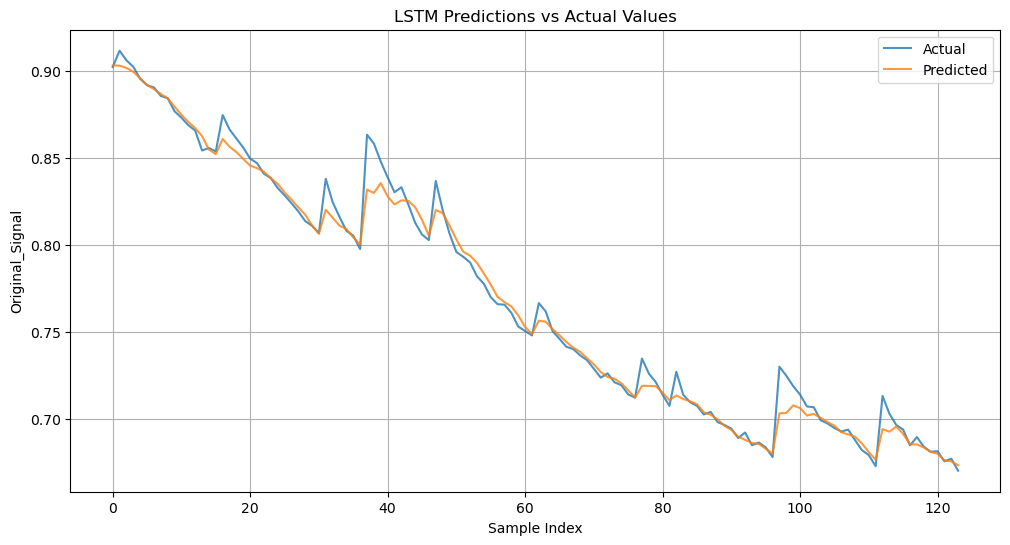


Output shapes:
Actual values shape: (124,)
Predicted values shape: (124,)


In [14]:
 #Plot the predictions vs actual values
plt.figure(figsize=(12, 6))
plt.plot(y_test_actual, label="Actual", alpha=0.8)
plt.plot(y_pred_actual, label="Predicted", alpha=0.8)
plt.title("LSTM Predictions vs Actual Values")
plt.xlabel("Sample Index")
plt.ylabel("Original_Signal")
plt.legend()
plt.grid(True)
plt.show()

print("\nOutput shapes:")
print(f"Actual values shape: {y_test_actual.shape}")
print(f"Predicted values shape: {y_pred_actual.shape}")

# B0005

In [7]:
# Define parameters
window_size = 8
Batch_Size = 32
train_files = ["B0018", "B0006", "B0007"]
test_file = "B0005"

In [8]:
# Step 1: Load and preprocess individual datasets
train_processed_data = {}
for file in train_files:
    data = load_and_preprocess_data(file_paths[file])
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(data)
    train_processed_data[file] = {
        'data': scaled_data,
        'columns': data.columns,
        'scaler': scaler
    }

test_data = load_and_preprocess_data(file_paths[test_file])
test_scaler = MinMaxScaler()
test_data_scaled = test_scaler.fit_transform(test_data)

In [9]:
# Step 2: Create sliding windows for each dataset
train_windows = {}
for file in train_files:
    #target_column_index = list(train_processed_data[file]['columns']).index("Original_Signal")
    target_column_index = list(train_processed_data[file]['columns']).index("SOH")
    X, y = create_sliding_window(
        train_processed_data[file]['data'], 
        window_size, 
        target_column_index
    )
    train_windows[file] = {'X': X, 'y': y}

In [ ]:
# Step 3: Combine the windowed data
X_combined = np.concatenate([train_windows[file]['X'] for file in train_files])
y_combined = np.concatenate([train_windows[file]['y'] for file in train_files])

print("Combined training data shape:", X_combined.shape)
print("Combined target data shape:", y_combined.shape)

# Create sliding windows for test data
test_target_column_index = test_data.columns.get_loc("SOH")
X_test, y_test = create_sliding_window(test_data_scaled, window_size, test_target_column_index)
print("Test data shape:", X_test.shape)

# Initialize KFold
kf = KFold(n_splits=3, shuffle=True, random_state=42)

# Dictionary to store metrics for each fold
fold_metrics = {}

# Train and evaluate the LSTM model with K-Fold Cross Validation
for fold, (train_index, val_index) in enumerate(kf.split(X_combined)):
    print(f"\nTraining on fold {fold + 1}")
    
    # Split the data
    X_train, X_val = X_combined[train_index], X_combined[val_index]
    y_train, y_val = y_combined[train_index], y_combined[val_index]
    
    # Build the LSTM model
    model = Sequential([
        Input(shape=(X_train.shape[1], X_train.shape[2])),
        LSTM(128, activation='relu', return_sequences=False),
        Dense(64, activation='relu'),
        Dense(1)
    ])
    
    # Compile model
    model.compile(optimizer='adam', loss='mse')
    
    # Early stopping
    early_stopping = EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True)
    
    # Train model
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=1000,
        batch_size=Batch_Size,
        callbacks=[early_stopping],
        verbose=1
    )
    
    # Store metrics
    fold_metrics[fold] = {
        'val_loss': min(history.history['val_loss']),
        'train_loss': min(history.history['loss'])
    }

# Print average metrics
avg_val_loss = np.mean([metrics['val_loss'] for metrics in fold_metrics.values()])
print(f"\nAverage validation loss across folds: {avg_val_loss}")

# Evaluate on test data
test_loss = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {test_loss}")

# Predict on test data
y_pred = model.predict(X_test)

# Inverse transform predictions
y_test_actual = test_scaler.inverse_transform(
    np.concatenate((np.zeros((len(y_test), test_data.shape[1] - 1)), y_test.reshape(-1, 1)), axis=1)
)[:, -1]
y_pred_actual = test_scaler.inverse_transform(
    np.concatenate((np.zeros((len(y_pred), test_data.shape[1] - 1)), y_pred), axis=1)
)[:, -1]


Combined training data shape: (444, 8, 4)
Combined target data shape: (444,)
Test data shape: (160, 8, 4)

Training on fold 1
Epoch 1/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - loss: 0.1605 - val_loss: 0.0579
Epoch 2/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0293 - val_loss: 0.0261
Epoch 3/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0161 - val_loss: 0.0111
Epoch 4/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0050 - val_loss: 0.0040
Epoch 5/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0029 - val_loss: 0.0017
Epoch 6/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0021 - val_loss: 0.0012
Epoch 7/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0014 - val_loss: 0.0015
Epoch 8/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0015 - val_loss: 9.9876e-04
Epoch 9/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0013 - val_loss: 0.0010
Epoch 10/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0012 - val_loss: 9.9020

In [ ]:
# Calculate metrics
mae = mean_absolute_error(y_test_actual, y_pred_actual)
mse = mean_squared_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_actual, y_pred_actual)
mape = np.mean(np.abs((y_test_actual - y_pred_actual) / y_test_actual)) * 100

# Print metrics
print("\nFinal Model Performance Metrics:")
print(f"Mean Absolute Error (MAE): {mae:.10f}")
print(f"Mean Squared Error (MSE): {mse:.10f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.10f}")
print(f"R2 Score: {r2:.7f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.7f}%")

In [ ]:
 #Plot the predictions vs actual values
plt.figure(figsize=(12, 6))
plt.plot(y_test_actual, label="Actual", alpha=0.8)
plt.plot(y_pred_actual, label="Predicted", alpha=0.8)
plt.title("LSTM B0005 Predictions vs Actual Values")
plt.xlabel("Sample Index")
plt.ylabel("Original_Signal")
plt.legend()
plt.grid(True)
plt.show()

print("\nOutput shapes:")
print(f"Actual values shape: {y_test_actual.shape}")
print(f"Predicted values shape: {y_pred_actual.shape}")

# B0006

In [ ]:
# Define parameters
window_size = 8
Batch_Size = 32
train_files = ["B0005", "B0018", "B0007"]
test_file = "B0006"

In [ ]:
# Step 1: Load and preprocess individual datasets
train_processed_data = {}
for file in train_files:
    data = load_and_preprocess_data(file_paths[file])
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(data)
    train_processed_data[file] = {
        'data': scaled_data,
        'columns': data.columns,
        'scaler': scaler
    }

test_data = load_and_preprocess_data(file_paths[test_file])
test_scaler = MinMaxScaler()
test_data_scaled = test_scaler.fit_transform(test_data)

In [ ]:
# Step 2: Create sliding windows for each dataset
train_windows = {}
for file in train_files:
    #target_column_index = list(train_processed_data[file]['columns']).index("Original_Signal")
    target_column_index = list(train_processed_data[file]['columns']).index("SOH")
    X, y = create_sliding_window(
        train_processed_data[file]['data'], 
        window_size, 
        target_column_index
    )
    train_windows[file] = {'X': X, 'y': y}

In [ ]:
# Step 3: Combine the windowed data
X_combined = np.concatenate([train_windows[file]['X'] for file in train_files])
y_combined = np.concatenate([train_windows[file]['y'] for file in train_files])

print("Combined training data shape:", X_combined.shape)
print("Combined target data shape:", y_combined.shape)

# Create sliding windows for test data
test_target_column_index = test_data.columns.get_loc("SOH")
X_test, y_test = create_sliding_window(test_data_scaled, window_size, test_target_column_index)
print("Test data shape:", X_test.shape)

# Initialize KFold
kf = KFold(n_splits=3, shuffle=True, random_state=42)

# Dictionary to store metrics for each fold
fold_metrics = {}

# Train and evaluate the LSTM model with K-Fold Cross Validation
for fold, (train_index, val_index) in enumerate(kf.split(X_combined)):
    print(f"\nTraining on fold {fold + 1}")
    
    # Split the data
    X_train, X_val = X_combined[train_index], X_combined[val_index]
    y_train, y_val = y_combined[train_index], y_combined[val_index]
    
    # Build the LSTM model
    model = Sequential([
        Input(shape=(X_train.shape[1], X_train.shape[2])),
        LSTM(128, activation='relu', return_sequences=False),
        Dense(64, activation='relu'),
        Dense(1)
    ])
    
    # Compile model
    model.compile(optimizer='adam', loss='mse')
    
    # Early stopping
    early_stopping = EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True)
    
    # Train model
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=1000,
        batch_size=Batch_Size,
        callbacks=[early_stopping],
        verbose=1
    )
    
    # Store metrics
    fold_metrics[fold] = {
        'val_loss': min(history.history['val_loss']),
        'train_loss': min(history.history['loss'])
    }

# Print average metrics
avg_val_loss = np.mean([metrics['val_loss'] for metrics in fold_metrics.values()])
print(f"\nAverage validation loss across folds: {avg_val_loss}")

# Evaluate on test data
test_loss = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {test_loss}")

# Predict on test data
y_pred = model.predict(X_test)

# Inverse transform predictions
y_test_actual = test_scaler.inverse_transform(
    np.concatenate((np.zeros((len(y_test), test_data.shape[1] - 1)), y_test.reshape(-1, 1)), axis=1)
)[:, -1]
y_pred_actual = test_scaler.inverse_transform(
    np.concatenate((np.zeros((len(y_pred), test_data.shape[1] - 1)), y_pred), axis=1)
)[:, -1]


In [ ]:
# Calculate metrics
mae = mean_absolute_error(y_test_actual, y_pred_actual)
mse = mean_squared_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_actual, y_pred_actual)
mape = np.mean(np.abs((y_test_actual - y_pred_actual) / y_test_actual)) * 100

# Print metrics
print("\nFinal Model Performance Metrics:")
print(f"Mean Absolute Error (MAE): {mae:.10f}")
print(f"Mean Squared Error (MSE): {mse:.10f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.10f}")
print(f"R2 Score: {r2:.7f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.7f}%")

In [ ]:
 #Plot the predictions vs actual values
plt.figure(figsize=(12, 6))
plt.plot(y_test_actual, label="Actual", alpha=0.8)
plt.plot(y_pred_actual, label="Predicted", alpha=0.8)
plt.title("LSTM B0006 Predictions vs Actual Values")
plt.xlabel("Sample Index")
plt.ylabel("Original_Signal")
plt.legend()
plt.grid(True)
plt.show()

print("\nOutput shapes:")
print(f"Actual values shape: {y_test_actual.shape}")
print(f"Predicted values shape: {y_pred_actual.shape}")

# B0007

In [ ]:
# Define parameters
window_size = 8
Batch_Size = 32
train_files = ["B0005", "B0006", "B0018"]
test_file = "B0007"

In [ ]:
# Step 1: Load and preprocess individual datasets
train_processed_data = {}
for file in train_files:
    data = load_and_preprocess_data(file_paths[file])
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(data)
    train_processed_data[file] = {
        'data': scaled_data,
        'columns': data.columns,
        'scaler': scaler
    }

test_data = load_and_preprocess_data(file_paths[test_file])
test_scaler = MinMaxScaler()
test_data_scaled = test_scaler.fit_transform(test_data)

In [ ]:
# Step 2: Create sliding windows for each dataset
train_windows = {}
for file in train_files:
    #target_column_index = list(train_processed_data[file]['columns']).index("Original_Signal")
    target_column_index = list(train_processed_data[file]['columns']).index("SOH")
    X, y = create_sliding_window(
        train_processed_data[file]['data'], 
        window_size, 
        target_column_index
    )
    train_windows[file] = {'X': X, 'y': y}

In [ ]:
# Step 3: Combine the windowed data
X_combined = np.concatenate([train_windows[file]['X'] for file in train_files])
y_combined = np.concatenate([train_windows[file]['y'] for file in train_files])

print("Combined training data shape:", X_combined.shape)
print("Combined target data shape:", y_combined.shape)

# Create sliding windows for test data
test_target_column_index = test_data.columns.get_loc("SOH")
X_test, y_test = create_sliding_window(test_data_scaled, window_size, test_target_column_index)
print("Test data shape:", X_test.shape)

# Initialize KFold
kf = KFold(n_splits=3, shuffle=True, random_state=42)

# Dictionary to store metrics for each fold
fold_metrics = {}

# Train and evaluate the LSTM model with K-Fold Cross Validation
for fold, (train_index, val_index) in enumerate(kf.split(X_combined)):
    print(f"\nTraining on fold {fold + 1}")
    
    # Split the data
    X_train, X_val = X_combined[train_index], X_combined[val_index]
    y_train, y_val = y_combined[train_index], y_combined[val_index]
    
    # Build the LSTM model
    model = Sequential([
        Input(shape=(X_train.shape[1], X_train.shape[2])),
        LSTM(128, activation='relu', return_sequences=False),
        Dense(64, activation='relu'),
        Dense(1)
    ])
    
    # Compile model
    model.compile(optimizer='adam', loss='mse')
    
    # Early stopping
    early_stopping = EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True)
    
    # Train model
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=1000,
        batch_size=Batch_Size,
        callbacks=[early_stopping],
        verbose=1
    )
    
    # Store metrics
    fold_metrics[fold] = {
        'val_loss': min(history.history['val_loss']),
        'train_loss': min(history.history['loss'])
    }

# Print average metrics
avg_val_loss = np.mean([metrics['val_loss'] for metrics in fold_metrics.values()])
print(f"\nAverage validation loss across folds: {avg_val_loss}")

# Evaluate on test data
test_loss = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {test_loss}")

# Predict on test data
y_pred = model.predict(X_test)

# Inverse transform predictions
y_test_actual = test_scaler.inverse_transform(
    np.concatenate((np.zeros((len(y_test), test_data.shape[1] - 1)), y_test.reshape(-1, 1)), axis=1)
)[:, -1]
y_pred_actual = test_scaler.inverse_transform(
    np.concatenate((np.zeros((len(y_pred), test_data.shape[1] - 1)), y_pred), axis=1)
)[:, -1]


In [ ]:
# Calculate metrics
mae = mean_absolute_error(y_test_actual, y_pred_actual)
mse = mean_squared_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_actual, y_pred_actual)
mape = np.mean(np.abs((y_test_actual - y_pred_actual) / y_test_actual)) * 100

# Print metrics
print("\nFinal Model Performance Metrics:")
print(f"Mean Absolute Error (MAE): {mae:.10f}")
print(f"Mean Squared Error (MSE): {mse:.10f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.10f}")
print(f"R2 Score: {r2:.7f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.7f}%")

In [ ]:
 #Plot the predictions vs actual values
plt.figure(figsize=(12, 6))
plt.plot(y_test_actual, label="Actual", alpha=0.8)
plt.plot(y_pred_actual, label="Predicted", alpha=0.8)
plt.title("LSTM B0007 Predictions vs Actual Values")
plt.xlabel("Sample Index")
plt.ylabel("Original_Signal")
plt.legend()
plt.grid(True)
plt.show()

print("\nOutput shapes:")
print(f"Actual values shape: {y_test_actual.shape}")
print(f"Predicted values shape: {y_pred_actual.shape}")